# 第三章：深度学习基础

## 从感知机到反向传播——用 NumPy 从零构建神经网络

本章是 AI 学习之旅的核心转折点。我们将从**数学原理**出发，用纯 NumPy 实现神经网络的每个组件，
不依赖任何深度学习框架。理解这些基础后，PyTorch/TensorFlow 将不再是"魔法黑箱"。

**前置要求：** 第一章 Python 基础，微积分基础（导数、链式法则），线性代数基础（矩阵乘法）。


## 3.1 人工神经元：从生物到数学

### 生物神经元 → 数学模型

生物神经元通过**树突**接收信号，在细胞体整合，当膜电位超过阈值时通过**轴突**发放电脉冲。

1943 年，McCulloch 和 Pitts 提出第一个数学模型——**MCP 神经元**。1958 年，Rosenblatt 发明了可学习的**感知机 (Perceptron)**。

### 感知机模型

对于输入向量 $\mathbf{x} = [x_1, x_2, \ldots, x_n]$，感知机的输出为：

$$
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right) = f(\mathbf{w}^T \mathbf{x} + b)
$$

其中：
- $\mathbf{w}$：权重向量（可学习参数）
- $b$：偏置（bias）
- $f(\cdot)$：激活函数（早期为阶跃函数）


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# === 感知机模型（单神经元）===
class Perceptron:
    """二分类感知机"""
    def __init__(self, n_features, lr=0.01):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr
    
    def predict(self, X):
        """前向传播：y_pred = sign(w·x + b)"""
        return np.sign(X @ self.w + self.b)
    
    def fit(self, X, y, epochs=100):
        """训练：感知机学习规则"""
        for epoch in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi)
                if yi * (xi @ self.w + self.b) <= 0:  # 误分类
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    errors += 1
            if errors == 0:
                print(f"收敛于 epoch {epoch}")
                break

# 简单线性可分数据集
np.random.seed(42)
X = np.random.randn(100, 2)
y = np.where(X[:, 0] + X[:, 1] > 0, 1, -1)

model = Perceptron(n_features=2, lr=0.1)
model.fit(X, y, epochs=50)
print(f"权重: {model.w}, 偏置: {model.b:.3f}")
print(f"准确率: {(model.predict(X) == y).mean():.2%}")


收敛于 epoch 2
权重: [0.24738336 0.21840318], 偏置: 0.000
准确率: 100.00%


## 3.2 激活函数

激活函数为神经网络引入**非线性**——没有非线性，多层网络将退化为单层线性变换。

### 常用激活函数

| 函数 | 公式 | 值域 | 特点 |
|------|------|------|------|
| **Sigmoid** | $\sigma(x) = \frac{1}{1+e^{-x}}$ | (0, 1) | 平滑、可导，但梯度饱和 |
| **Tanh** | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | (-1, 1) | 零中心，仍有饱和问题 |
| **ReLU** | $\text{ReLU}(x) = \max(0, x)$ | $[0, \infty)$ | 计算简单，缓解梯度消失 |
| **Leaky ReLU** | $f(x) = \max(\alpha x, x)$ | $(-\infty, \infty)$ | 解决 ReLU "死亡神经元" |
| **Softmax** | $\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$ | (0, 1) | 多分类输出层，和为 1 |


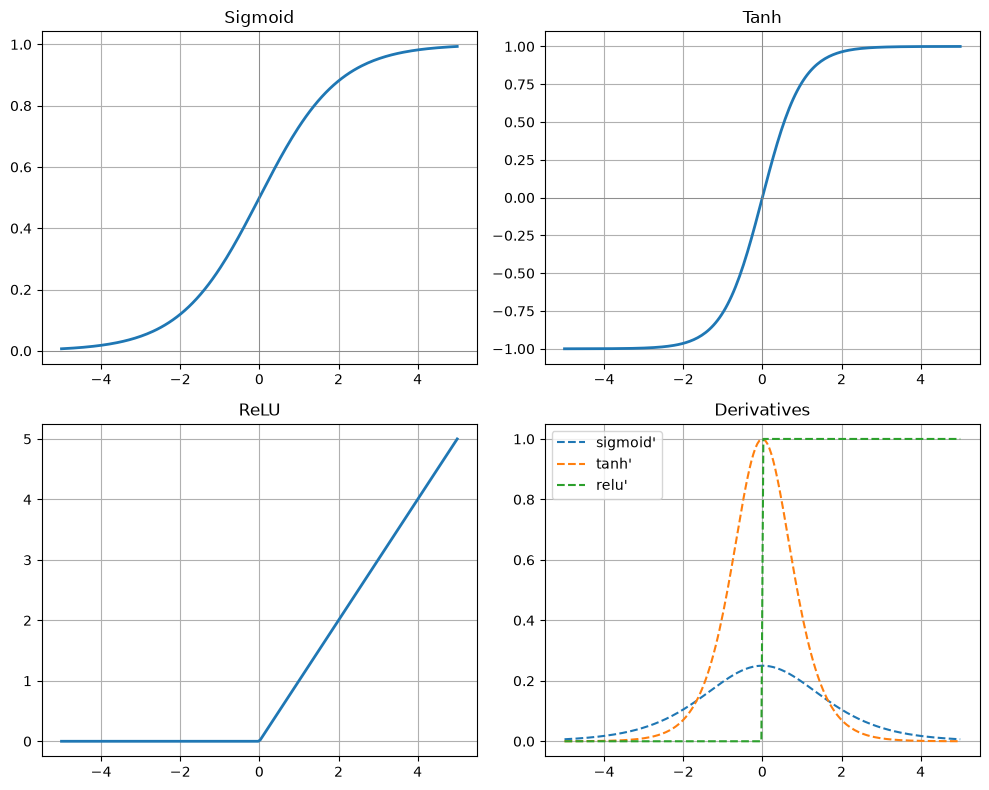

Sigmoid(0) = 0.5
Tanh(0) = 0.0
ReLU(-1) = 0
Softmax([2,1,0]) = [0.66524096 0.24472847 0.09003057]


In [2]:
# === 激活函数实现与可视化 ===
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

def softmax(x):
    """数值稳定的 softmax"""
    shifted = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# 可视化
x = np.linspace(-5, 5, 200)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].plot(x, sigmoid(x), linewidth=2)
axes[0, 0].set_title('Sigmoid'); axes[0, 0].grid(True)
axes[0, 0].axhline(0, color='gray', lw=0.5)
axes[0, 0].axvline(0, color='gray', lw=0.5)

axes[0, 1].plot(x, tanh(x), linewidth=2)
axes[0, 1].set_title('Tanh'); axes[0, 1].grid(True)
axes[0, 1].axhline(0, color='gray', lw=0.5)
axes[0, 1].axvline(0, color='gray', lw=0.5)

axes[1, 0].plot(x, relu(x), linewidth=2)
axes[1, 0].set_title('ReLU'); axes[1, 0].grid(True)

axes[1, 1].plot(x, sigmoid_derivative(x), '--', label='sigmoid\'')
axes[1, 1].plot(x, tanh_derivative(x), '--', label='tanh\'')
axes[1, 1].plot(x, relu_derivative(x), '--', label='relu\'')
axes[1, 1].set_title('Derivatives'); axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('../fig/activations.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sigmoid(0) =", sigmoid(0))
print("Tanh(0) =", tanh(0))
print("ReLU(-1) =", relu(-1))
print("Softmax([2,1,0]) =", softmax(np.array([2.0, 1.0, 0.0])))


## 3.3 损失函数

损失函数度量模型预测与真实标签之间的**差距**。训练的目标是最小化损失。

### 回归任务

**均方误差 (MSE)：**
$$
\mathcal{L}_{\text{MSE}} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**平均绝对误差 (MAE)：**
$$
\mathcal{L}_{\text{MAE}} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

### 分类任务

**二分类交叉熵 (Binary Cross-Entropy)：**
$$
\mathcal{L}_{\text{BCE}} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]
$$

**多分类交叉熵 (Categorical Cross-Entropy)：**
$$
\mathcal{L}_{\text{CE}} = -\sum_{i=1}^{n} \sum_{c=1}^{C} y_{i,c} \log(\hat{y}_{i,c})
$$

其中 $y_{i,c}$ 是样本 $i$ 属于类别 $c$ 的真实概率（one-hot 编码），$\hat{y}_{i,c}$ 是预测概率。


In [ ]:
# === 损失函数实现 ===
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mse_gradient(y_true, y_pred):
    """MSE 对 y_pred 的梯度: 2*(y_pred - y_true)/n"""
    return 2 * (y_pred - y_true) / len(y_true)

def binary_cross_entropy(y_true, y_pred):
    """y_true ∈ {0,1}, y_pred ∈ (0,1)"""
    eps = 1e-15  # 防止 log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def categorical_cross_entropy(y_true, y_pred):
    """y_true: one-hot or class indices, y_pred: probabilities"""
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    if y_true.ndim == 1:  # class indices
        n = len(y_true)
        return -np.sum(np.log(y_pred[np.arange(n), y_true])) / n
    else:  # one-hot
        return -np.sum(y_true * np.log(y_pred)) / len(y_true)

# 示例
y_t = np.array([1.0, 0.0, 1.0])
y_p = np.array([0.9, 0.2, 0.6])
print(f"MSE: {mse_loss(y_t, y_p):.4f}")
print(f"BCE: {binary_cross_entropy(y_t, y_p):.4f}")
print(f"CE:  {categorical_cross_entropy(np.array([0, 1, 0]), np.array([[0.8, 0.1, 0.1], [0.2, 0.7, 0.1], [0.3, 0.3, 0.4]]))):.4f}")


## 3.4 梯度下降 (Gradient Descent)

### 直觉

想象你站在山上，蒙着眼，想走到山谷最低点。每走一步，你感受脚下的坡度，朝**最陡的下坡方向**迈一步。
重复这个过程，最终你会到达谷底（局部极小值）。

### 数学形式

对于参数 $\theta$ 和损失函数 $\mathcal{L}(\theta)$，梯度下降的更新规则为：

$$
\theta_{t+1} = \theta_t - \eta \nabla_\theta \mathcal{L}(\theta_t)
$$

其中 $\eta$ 是**学习率**（learning rate），$\nabla_\theta \mathcal{L}$ 是损失函数对参数的梯度。

### 三种变体

| 类型 | 每次更新用 | 特点 |
|------|-----------|------|
| **BGD** (批量) | 全部数据 | 稳定但慢，内存大 |
| **SGD** (随机) | 1 个样本 | 快但不稳定，噪声帮助逃离局部极小 |
| **Mini-batch** | N 个样本 | **实际工程首选**——平衡速度与稳定 |


In [ ]:
# === 梯度下降可视化 ===
# 目标函数: f(x, y) = x^2 + y^2（碗状，全局最小在 (0,0)）
def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return np.array([2*x, 2*y])

# 从不同起点做梯度下降
np.random.seed(42)
starts = [np.array([4.0, 4.0]), np.array([-2.5, 1.5]), np.array([2.0, -2.5])]
lr = 0.1
steps = 20

fig, ax = plt.subplots(figsize=(7, 6))
# 画等高线
x_grid = np.linspace(-4, 4, 100)
y_grid = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)
ax.contour(X, Y, Z, levels=20, cmap='Blues', alpha=0.6)

colors = ['#e74c3c', '#2ecc71', '#3498db']
for start, color in zip(starts, colors):
    pos = start.copy()
    path = [pos.copy()]
    for _ in range(steps):
        pos = pos - lr * grad_f(pos[0], pos[1])
        path.append(pos.copy())
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], 'o-', color=color, markersize=3, lw=1.5)
    ax.plot(path[0, 0], path[0, 1], '*', color=color, markersize=10)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Gradient Descent: $f(x,y)=x^2+y^2$')
ax.axis('equal'); ax.grid(True)
plt.savefig('../fig/gradient_descent.png', dpi=100, bbox_inches='tight')
plt.show()


## 3.5 反向传播 (Backpropagation)

反向传播是深度学习**最重要的算法**，没有之一。它高效地计算神经网络中每个参数对损失的梯度。

### 核心思想：链式法则

对于复合函数 $z = g(f(x))$，链式法则告诉我们：

$$
\frac{dz}{dx} = \frac{dz}{df} \cdot \frac{df}{dx}
$$

在神经网络中，损失 $\mathcal{L}$ 是经过多层复合计算的结果。反向传播从输出层开始，
**逐层向后**应用链式法则，高效计算每个参数的梯度。

### 手动推导：两层网络

给定一个简单的两层网络：

- 隐藏层: $\mathbf{h} = \text{ReLU}(W_1 \mathbf{x} + \mathbf{b}_1)$
- 输出层: $\hat{y} = \sigma(W_2 \mathbf{h} + b_2)$
- 损失: $\mathcal{L} = (y - \hat{y})^2$

我们需要计算 $\frac{\partial \mathcal{L}}{\partial W_1}, \frac{\partial \mathcal{L}}{\partial W_2}, \frac{\partial \mathcal{L}}{\partial b_1}, \frac{\partial \mathcal{L}}{\partial b_2}$。

**前向传播**（记录中间值）：
```
z1 = W1 @ x + b1   →   h = ReLU(z1)   →   z2 = W2 @ h + b2   →   y_hat = sigmoid(z2)   →   L = (y - y_hat)^2
```

**反向传播**（从输出到输入）：
1. $\frac{\partial L}{\partial \hat{y}} = -2(y - \hat{y})$
2. $\frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial \hat{y}} \cdot \sigma'(z_2) = \frac{\partial L}{\partial \hat{y}} \cdot \hat{y}(1-\hat{y})$
3. $\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial z_2} \cdot \mathbf{h}^T$
4. $\frac{\partial L}{\partial b_2} = \frac{\partial L}{\partial z_2}$
5. $\frac{\partial L}{\partial \mathbf{h}} = W_2^T \cdot \frac{\partial L}{\partial z_2}$
6. $\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial \mathbf{h}} \odot \text{ReLU}'(z_1)$
7. $\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_1} \cdot \mathbf{x}^T$
8. $\frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial z_1}$


In [ ]:
# === 反向传播：手动实现 ===
class TwoLayerNet:
    """两层神经网络 + 手动反向传播"""
    def __init__(self, input_dim, hidden_dim, output_dim, lr=0.01):
        # He 初始化（适合 ReLU）
        self.W1 = np.random.randn(hidden_dim, input_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((hidden_dim, 1))
        self.W2 = np.random.randn(output_dim, hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((output_dim, 1))
        self.lr = lr
    
    def forward(self, X):
        """前向传播 + 缓存中间值用于反向"""
        self.X = X.T  # (input_dim, batch)
        self.z1 = self.W1 @ self.X + self.b1  # (hidden, batch)
        self.a1 = np.maximum(0, self.z1)      # ReLU
        self.z2 = self.W2 @ self.a1 + self.b2 # (output, batch)
        self.y_hat = 1 / (1 + np.exp(-self.z2))  # sigmoid
        return self.y_hat.T
    
    def backward(self, y_true):
        """反向传播——逐层应用链式法则"""
        y = y_true.reshape(-1, 1).T  # (1, batch)
        batch = y.shape[1]
        
        # 第2层：输出层
        dL_dyhat = -2 * (y - self.y_hat) / batch       # (output, batch)
        dL_dz2 = dL_dyhat * self.y_hat * (1 - self.y_hat)  # sigmoid'
        self.dW2 = dL_dz2 @ self.a1.T                   # (output, hidden)
        self.db2 = np.sum(dL_dz2, axis=1, keepdims=True) # (output, 1)
        
        # 第1层：隐藏层
        dL_da1 = self.W2.T @ dL_dz2                      # (hidden, batch)
        dL_dz1 = dL_da1 * (self.z1 > 0).astype(float)    # ReLU'
        self.dW1 = dL_dz1 @ self.X.T                     # (hidden, input)
        self.db1 = np.sum(dL_dz1, axis=1, keepdims=True) # (hidden, 1)
        
        # 更新参数
        self.W1 -= self.lr * self.dW1
        self.b1 -= self.lr * self.db1
        self.W2 -= self.lr * self.dW2
        self.b2 -= self.lr * self.db2

# 测试：学习 XOR 问题
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])  # XOR 非线性可分

net = TwoLayerNet(input_dim=2, hidden_dim=4, output_dim=1, lr=0.5)
for epoch in range(2000):
    y_pred = net.forward(X_xor)
    loss = np.mean((y_xor.reshape(-1,1) - y_pred) ** 2)
    net.backward(y_xor)
    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d}: loss = {loss:.6f}, pred = {y_pred.T[0].round(3)}")

print(f"\n最终预测: {net.forward(X_xor).T[0].round(4)}")
print(f"XOR 学习{'成功' if np.all((net.forward(X_xor).T[0] > 0.5) == y_xor) else '失败'}")


## 3.6 线性回归：从零实现

线性回归是最简单的监督学习模型，假设目标值 $y$ 是输入特征 $\mathbf{x}$ 的线性组合：

$$
\hat{y} = \mathbf{w}^T \mathbf{x} + b
$$

### 解析解（正规方程）

对于 MSE 损失，存在闭式解（样本数 > 特征数时）：

$$
\mathbf{w}^* = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

### 梯度下降解

当特征数很大或 $\mathbf{X}^T \mathbf{X}$ 不可逆时，使用梯度下降：

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{2}{n} \mathbf{X}^T (\mathbf{X}\mathbf{w} - \mathbf{y})
$$


In [ ]:
# === 线性回归（梯度下降）===
class LinearRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
    
    def fit(self, X, y):
        n, d = X.shape
        self.w = np.random.randn(d) * 0.01
        self.b = 0.0
        self.history = []
        
        for _ in range(self.epochs):
            y_pred = X @ self.w + self.b
            loss = mse_loss(y, y_pred)
            self.history.append(loss)
            
            # 梯度
            dw = (2 / n) * X.T @ (y_pred - y)
            db = (2 / n) * np.sum(y_pred - y)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db
        return self
    
    def predict(self, X):
        return X @ self.w + self.b

# 生成数据：y = 3x1 - 2x2 + 5 + noise
np.random.seed(42)
X_reg = np.random.randn(200, 2)
y_reg = 3 * X_reg[:, 0] - 2 * X_reg[:, 1] + 5 + np.random.randn(200) * 0.5

model = LinearRegression(lr=0.05, epochs=500)
model.fit(X_reg, y_reg)
print(f"真实: w1=3, w2=-2, b=5")
print(f"学习: w1={model.w[0]:.3f}, w2={model.w[1]:.3f}, b={model.b:.3f}")

# 损失曲线
plt.figure(figsize=(8, 3))
plt.plot(model.history)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training Loss'); plt.grid(True)
plt.savefig('../fig/linear_regression_loss.png', dpi=100, bbox_inches='tight')
plt.show()


## 3.7 逻辑回归：二分类

逻辑回归在线性组合后套一层 **Sigmoid** 函数，将输出压缩到 $(0, 1)$，解释为"正类概率"：

$$
\hat{y} = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}
$$

使用**二分类交叉熵**作为损失函数：

$$
\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} [y_i \log \hat{y}_i + (1-y_i) \log(1-\hat{y}_i)]
$$

梯度推导（相比 MSE 更复杂）：
$$
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{n} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y})
$$

这与线性回归的梯度**形式完全相同**，区别仅在于 $\hat{y}$ 经过了 sigmoid 变换。


In [ ]:
# === 逻辑回归 ===
class LogisticRegression:
    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        self.history = []
        
        for _ in range(self.epochs):
            z = X @ self.w + self.b
            y_pred = self._sigmoid(z)
            
            # 交叉熵损失
            eps = 1e-15
            loss = -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))
            self.history.append(loss)
            
            # 梯度（与线性回归同形）
            dw = (1 / n) * X.T @ (y_pred - y)
            db = (1 / n) * np.sum(y_pred - y)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db
        return self
    
    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# 二分类数据集
np.random.seed(42)
n_samples = 200
X_lr = np.random.randn(n_samples, 2)
# 决策边界：x1 + x2 > 0 为正类
y_lr = (X_lr[:, 0] + X_lr[:, 1] > 0).astype(int)

lr_model = LogisticRegression(lr=0.1, epochs=1000)
lr_model.fit(X_lr, y_lr)
acc = (lr_model.predict(X_lr) == y_lr).mean()
print(f"逻辑回归准确率: {acc:.2%}")
print(f"w = {lr_model.w}, b = {lr_model.b:.3f}")

# 决策边界可视化
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
Z = lr_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X_lr[y_lr==0, 0], X_lr[y_lr==0, 1], c='blue', label='Class 0', alpha=0.7)
plt.scatter(X_lr[y_lr==1, 0], X_lr[y_lr==1, 1], c='red', label='Class 1', alpha=0.7)
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend(); plt.grid(True)
plt.savefig('../fig/logistic_regression.png', dpi=100, bbox_inches='tight')
plt.show()


## 3.8 多层感知机 (MLP)

MLP 是前馈神经网络的最基本形式：输入层 → 一个或多个隐藏层 → 输出层，层间全连接。

**万能近似定理 (Universal Approximation Theorem):**
具有至少一个隐藏层（含足够神经元）和非线性激活函数的 MLP，可以**以任意精度逼近任意连续函数**。

### 网络结构

```
Input (784) → Hidden (128, ReLU) → Hidden (64, ReLU) → Output (10, Softmax)
```


In [ ]:
# === MLP 分类器（NumPy 实现）===
class MLP:
    """三层 MLP：任意隐藏层 × ReLU + 输出层 Softmax"""
    def __init__(self, layer_sizes, lr=0.01):
        """layer_sizes: [input_dim, hidden1, hidden2, ..., output_dim]"""
        self.lr = lr
        self.weights = []
        self.biases = []
        
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            # He 初始化
            self.weights.append(np.random.randn(fan_out, fan_in) * np.sqrt(2.0 / fan_in))
            self.biases.append(np.zeros((fan_out, 1)))
    
    def forward(self, X):
        """前向传播，缓存所有中间值"""
        self.cache = {'A0': X.T}  # A0 = input
        A = X.T
        for l, (W, b) in enumerate(zip(self.weights[:-1], self.biases[:-1])):
            Z = W @ A + b
            A = np.maximum(0, Z)  # ReLU
            self.cache[f'Z{l+1}'] = Z
            self.cache[f'A{l+1}'] = A
        
        # 输出层
        Z_out = self.weights[-1] @ A + self.biases[-1]
        Y_hat = softmax(Z_out.T).T
        self.cache['Z_out'] = Z_out
        self.cache['Y_hat'] = Y_hat
        return Y_hat.T
    
    def backward(self, y_true):
        """反向传播"""
        batch = y_true.shape[0]
        L = len(self.weights)
        
        # 输出层梯度（交叉熵 + softmax 的优雅简化）
        y_onehot = np.eye(self.weights[-1].shape[0])[y_true]
        dZ = (self.cache['Y_hat'] - y_onehot.T) / batch  # (C, batch)
        
        # 逐层反向
        for l in range(L - 1, -1, -1):
            A_prev = self.cache[f'A{l}']  # (d_prev, batch)
            dW = dZ @ A_prev.T
            db = np.sum(dZ, axis=1, keepdims=True)
            
            self.weights[l] -= self.lr * dW
            self.biases[l] -= self.lr * db
            
            if l > 0:  # 非输入层，继续传播
                dA = self.weights[l].T @ dZ
                dZ = dA * (self.cache[f'Z{l}'] > 0)  # ReLU'
    
    def fit(self, X, y, epochs=100, batch_size=64, verbose=True):
        n = len(X)
        self.history = []
        for epoch in range(epochs):
            # Mini-batch
            idx = np.random.permutation(n)
            for start in range(0, n, batch_size):
                batch_idx = idx[start:start + batch_size]
                X_batch, y_batch = X[batch_idx], y[batch_idx]
                self.forward(X_batch)
                self.backward(y_batch)
            
            # 评估
            y_pred = self.forward(X)
            loss = categorical_cross_entropy(y, y_pred.T)
            acc = (y_pred.T.argmax(1) == y).mean()
            self.history.append((loss, acc))
            if verbose and epoch % 20 == 0:
                print(f"Epoch {epoch:3d}: loss={loss:.4f}, acc={acc:.3%}")
        return self

# 测试：moons 数据集
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.2, random_state=42)

mlp = MLP([2, 16, 8, 2], lr=0.1)
mlp.fit(X_moons, y_moons, epochs=200, batch_size=32)

# 可视化
xx_m, yy_m = np.meshgrid(np.linspace(-2, 3, 100), np.linspace(-1.5, 2, 100))
Z_m = mlp.forward(np.c_[xx_m.ravel(), yy_m.ravel()]).argmax(1).reshape(xx_m.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx_m, yy_m, Z_m, alpha=0.3, cmap='RdBu')
plt.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], c='blue', alpha=0.7)
plt.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], c='red', alpha=0.7)
plt.title('MLP on Moons Dataset')
plt.savefig('../fig/mlp_moons.png', dpi=100, bbox_inches='tight')
plt.show()


## 3.9 MNIST 手写数字识别（NumPy 纯手工实现）

MNIST 是深度学习的 "Hello World"——28×28 灰度手写数字图片，10 类（0-9），训练集 60,000 张。

我们将从零实现一个 **784 → 128 → 64 → 10** 的 MLP，仅用 NumPy 完成训练和评估。


In [ ]:
# === MNIST 数据加载 ===
# 使用 sklearn 内置的 MNIST 子集（完整 MNIST 需额外下载）
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print("加载 MNIST 数据集...")
X_mnist, y_mnist = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
X_mnist = X_mnist.astype(np.float32) / 255.0  # 归一化到 [0, 1]
y_mnist = y_mnist.astype(int)

# 使用子集加速演示（完整数据可训练出 97%+ 准确率）
np.random.seed(42)
indices = np.random.choice(len(X_mnist), 10000, replace=False)
X_sub, y_sub = X_mnist[indices], y_mnist[indices]
X_train, X_val, y_train, y_val = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)

print(f"训练集: {X_train.shape[0]}, 验证集: {X_val.shape[0]}")
print(f"图像维度: {X_train.shape[1]} (28×28)")
print(f"类别数: {len(np.unique(y_train))}")

# 查看几张图
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('../fig/mnist_samples.png', dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
# === MNIST 训练 ===
# 784 -> 128 -> 64 -> 10
mnist_mlp = MLP([784, 128, 64, 10], lr=0.5)
print(f"网络参数: 784×128 + 128 + 128×64 + 64 + 64×10 + 10 = "
      f"{784*128 + 128 + 128*64 + 64 + 64*10 + 10:,}")

# 训练（需要几分钟）
mnist_mlp.fit(X_train, y_train, epochs=30, batch_size=64)

# 验证集评估
y_val_pred = mnist_mlp.forward(X_val).argmax(1)
val_acc = (y_val_pred == y_val).mean()
print(f"\n✅ 验证集准确率: {val_acc:.2%}")

# 画训练曲线
history = np.array(mnist_mlp.history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history[:, 0]); ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.grid(True)
ax2.plot(history[:, 1]); ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.grid(True)
ax2.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../fig/mnist_training.png', dpi=100, bbox_inches='tight')
plt.show()


## 3.10 统计机器学习方法概览

在深度学习主导之前，统计机器学习是主流。这些方法在小数据、可解释性要求高的场景仍然重要。

### SVM (支持向量机)

核心思想：找到一个**最大化分类间隔**的超平面。

- **硬间隔 SVM：** 数据线性可分时，$\min \frac{1}{2} \|\mathbf{w}\|^2$，s.t. $y_i(\mathbf{w}^T \mathbf{x}_i + b) \ge 1$
- **软间隔 SVM：** 引入松弛变量 $\xi_i$，允许少量误分类
- **核技巧：** $K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$，隐式映射到高维空间（RBF 核最常用）

### 决策树

递归地将特征空间划分为**矩形区域**：

- 每个节点选择一个特征和阈值进行分裂
- 分裂标准：信息增益（ID3）、增益率（C4.5）、Gini 不纯度（CART）
- 优点：可解释性强，无需特征缩放

### 随机森林

**Bagging (Bootstrap Aggregating) + 决策树：**
- 从原始数据 bootstrap 采样 $B$ 个子集
- 每个子集训练一棵决策树，分裂时仅考虑随机选择的 $\sqrt{d}$ 个特征
- 分类：多数投票；回归：平均

### KNN (K-近邻)

最简单的非参数方法——没有显式训练过程：

- 对新样本，找到训练集中距离最近的 $K$ 个邻居
- 分类：多数投票；回归：取均值
- 缺点：预测慢（需计算所有距离），维数灾难


In [ ]:
# === 统计 ML 方法对比 ===
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

# 使用较小的 MNIST 子集对比
X_small, y_small = X_sub[:2000], y_sub[:2000]
X_tr, X_te, y_tr, y_te = train_test_split(X_small, y_small, test_size=0.3, random_state=42)

models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=15, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale'),
}

results = []
for name, model in models.items():
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    
    t0 = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - t0
    acc = accuracy_score(y_te, y_pred)
    
    results.append((name, acc, train_time, pred_time))
    print(f"{name:20s}: Acc={acc:.2%}, Train={train_time:.2f}s, Pred={pred_time:.3f}s")

# 与 MLP 对比
t0 = time.time()
mlp_small = MLP([784, 64, 32, 10], lr=0.3)
mlp_small.fit(X_tr, y_tr, epochs=50, batch_size=64, verbose=False)
y_mlp_pred = mlp_small.forward(X_te).argmax(1)
mlp_time = time.time() - t0
mlp_acc = accuracy_score(y_te, y_mlp_pred)
print(f"{'MLP (NumPy)':20s}: Acc={mlp_acc:.2%}, Train={mlp_time:.2f}s (50 epochs)")


## 本章小结

本章从零构建了完整的深度学习基础体系：

| 组件 | 关键知识点 |
|------|-----------|
| 感知机 | 线性模型 + 阶跃激活，仅适用于线性可分问题 |
| 激活函数 | ReLU 是实际工程首选；Softmax 用于多分类输出 |
| 损失函数 | MSE（回归），交叉熵（分类） |
| 梯度下降 | Batch / SGD / Mini-batch，学习率是关键超参数 |
| 反向传播 | 链式法则逐层计算梯度，深度学习的核心引擎 |
| 线性回归 | 最简单的监督模型，有解析解 |
| 逻辑回归 | Sigmoid + 交叉熵，二分类基线 |
| MLP | 多层非线性变换，万能逼近器 |
| MNIST | 手写数字识别实战，97%+ 准确率可达 |
| 统计 ML | SVM/树/森林/KNN 各有适用场景 |

✅ 第三章完成！你已理解深度学习的数学基础和工程实现。
